In [83]:
import time
import numpy as np
from pynq import Overlay, allocate

# ============================================================
# CONFIGURATION
# ============================================================

BITFILE = "design_1.bit"

NUM_INPUTS = 3      # u, v, I
NUM_OUTPUTS = 2     # u, v

Q_FRAC_BITS = 24
Q = 1 << Q_FRAC_BITS

DT = 1e-3
T_END = 0.002

A = 0.7
INV_E = 1.0 / 0.08

SIGMA = 0.1
SIGMA_SQRT_DT = SIGMA * np.sqrt(DT)

SEED = 12345678

N = 102400
# ============================================================
# FIXED POINT HELPERS
# ============================================================

def float_to_q824(x):
    return int(np.round(x * (1 << Q_FRAC_BITS)))

def q824_to_float(x):
    return x / float(1 << Q_FRAC_BITS)

# ============================================================
# LOAD BITSTREAM
# ============================================================

ol = Overlay(BITFILE)
accel = ol.accelerator_0

print(accel.register_map)

accel.register_map.dt = float_to_q824(DT)
accel.register_map.a = float_to_q824(A)
accel.register_map.inv_e = float_to_q824(INV_E)

accel.register_map.sigma_sqrt_dt = \
    float_to_q824(SIGMA_SQRT_DT)

accel.register_map.seed = SEED
accel.register_map.reseed = 1

# ============================================================
# PACKED INTERFACE
# ============================================================

job_dtype = np.dtype([
    ("word", np.uint64, 2)      # 128 bits
])

result_dtype = np.dtype([
    ("word", np.uint64, 1)      # 64 bits
])

# ============================================================
# PACKING
# ============================================================

def pack_job(values):

    packed = 0

    for i, v in enumerate(values):
        packed |= (
            int(np.uint32(v))
            << (32 * i)
        )

    return np.array([
        packed & ((1 << 64) - 1),
        (packed >> 64) & ((1 << 64) - 1)
    ], dtype=np.uint64)

def unpack_result(word):

    packed = int(word)

    out = []

    for i in range(NUM_OUTPUTS):

        v = (
            packed >> (32 * i)
        ) & 0xffffffff

        if v & 0x80000000:
            v -= 0x100000000

        out.append(v)

    return out

# ============================================================
# BUILD FPGA JOBS
# ============================================================

def build_jobs(state, jobs):

    for job in range(N):

        base = job * NUM_INPUTS

        inp = np.array([
            float_to_q824(state[base + 0]),  # u
            float_to_q824(state[base + 1]),  # v
            float_to_q824(state[base + 2]),  # I
        ], dtype=np.int32)

        jobs[job]["word"][:] = pack_job(inp)

# ============================================================
# PROCESS FPGA RESULTS
# ============================================================

def process_results(state, results):

    for job in range(N):

        base = job * NUM_INPUTS

        out = unpack_result(
            results[job]["word"]
        )

        state[base + 0] = q824_to_float(out[0])   # u
        state[base + 1] = q824_to_float(out[1])   # v
        state[base + 2] = 0
        # unchanged

# ============================================================
# FPGA EXECUTION
# ============================================================

def run_accelerator(jobs, results):

    n = len(jobs)

    jobs.flush()

    accel.write(0x10, jobs.physical_address)
    accel.write(0x1C, results.physical_address)
    accel.write(0x28, n)

    accel.write(0x00, 1)

    while (accel.read(0x00) & 0x2) == 0:
        pass

    results.invalidate()

# ============================================================
# SIMULATION
# ============================================================

def simulate(initial_state):

    state = initial_state.copy()

    num_steps = int(T_END / DT)

    print(
        "About to integrate for",
        num_steps,
        "steps."
    )

    jobs = allocate(
        shape=(N,),
        dtype=job_dtype
    )

    results = allocate(
        shape=(N,),
        dtype=result_dtype
    )

    elapsed = 0.0

    for step in range(num_steps):

        print("Step", step)

        build_jobs(
            state,
            jobs
        )

        start = time.perf_counter()

        run_accelerator(
            jobs,
            results
        )

        elapsed += (
            time.perf_counter() - start
        )

        # Important:
        # only reseed once
        if step == 0:
            accel.register_map.reseed = 0

        process_results(
            state,
            results
        )

    total_jobs = (
        N * num_steps
    )

    print()
    print("================================")
    print("Simulation completed")
    print("================================")
    print(f"N             : {N}")
    print(f"Steps         : {num_steps}")
    print(f"Total jobs    : {total_jobs}")
    print(f"Elapsed       : {elapsed:.6f} s")
    print(f"MJobs/s       : {total_jobs/elapsed/1e6:.3f}")
    print(f"Steps/s       : {num_steps/elapsed:.3f}")
    print("================================")

    jobs.close()
    results.close()

    return state


RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  jobs_1 = Register(jobs=write-only),
  jobs_2 = Register(jobs=write-only),
  results_1 = Register(results=write-only),
  results_2 = Register(results=write-only),
  num_jobs = Register(num_jobs=write-only),
  dt = Register(dt=write-only),
  a = Register(a=write-only),
  inv_e = Register(inv_e=write-only),
  sigma_sqrt_dt = Register(sigma_sqrt_dt=write-only),
  seed = Register(seed=write-only),
  reseed = Register(reseed=write-only, RESERVED=write-only)
}


/tmp/ipykernel_2244/3728064242.py:66: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  result_dtype = np.dtype([


In [84]:
state0 = np.zeros(
    N * NUM_INPUTS,
    dtype=np.float32
)

for neuron in range(N):

    base = neuron * NUM_INPUTS

    state0[base + 0] = 0.0      # u
    state0[base + 1] = 0.0      # v
    state0[base + 2] = 0.5      # I

state_final = simulate(
    state0
)

print("Initial:")
print(state0[:12])

print()

print("Final:")
print(state_final[::3])

About to integrate for 2 steps.
Step 0
Step 1

Simulation completed
N             : 102400
Steps         : 2
Total jobs    : 204800
Elapsed       : 0.005835 s
MJobs/s       : 35.099
Steps/s       : 342.766
Initial:
[0.  0.  0.5 0.  0.  0.5 0.  0.  0.5 0.  0.  0.5]

Final:
[ 0.00556713  0.00132823  0.01273763 ...  0.00370014  0.00187516
 -0.00150758]


(array([0.0000e+00, 0.0000e+00, 0.0000e+00, 5.0000e+00, 5.0000e+00,
        7.3000e+01, 2.4200e+02, 5.5300e+02, 1.3700e+03, 2.6570e+03,
        4.6320e+03, 7.0320e+03, 9.5600e+03, 1.1992e+04, 1.2879e+04,
        1.3166e+04, 1.1876e+04, 9.6770e+03, 6.9590e+03, 4.7510e+03,
        2.6790e+03, 1.3770e+03, 6.1200e+02, 2.1000e+02, 7.6000e+01,
        1.4000e+01, 3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]),
 array([-0.01581139, -0.0147573 , -0.0137032 , -0.01264911, -0.01159502,
        -0.01054093, -0.00948683, -0.00843274, -0.00737865, -0.00632456,
        -0.00527046, -0.00421637, -0.00316228, -0.00210819, -0.00105409,
         0.        ,  0.00105409,  0.00210819,  0.00316228,  0.00421637,
         0.00527046,  0.00632456,  0.00737865,  0.00843274,  0.00948683,
         0.01054093,  0.01159502,  0.01264911,  0.0137032 ,  0.0147573 ,
         0.01581139], dtype=float32),
 [<matplotlib.patches.Polygon at 0xb2eb3688>])

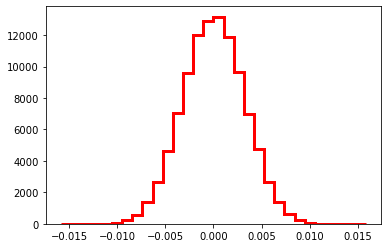

In [65]:
import matplotlib.pyplot as plt
import numpy as np

rng = state_final[::3]
plt.hist(rng, bins=30, range=[-5*SIGMA_SQRT_DT, 5*SIGMA_SQRT_DT], histtype='step',edgecolor='r',linewidth=3)

In [81]:
!g++ -O3 benchmark.cpp -o benchmark

In [82]:
!./benchmark

About to integrate for 2 steps.

Simulation completed
N             : 102400
Steps         : 2
Total jobs    : 204800
Elapsed       : 0.0465427 s
MJobs/s       : 4.40026
Steps/s       : 42.9713
